In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow import keras
from keras import regularizers
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [3]:
X_train.shape

(50000, 32, 32, 3)

In [4]:
print('Number of categories:', len(np.unique(y_train)))

Number of categories: 10


In [5]:
input_dim = 3072
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)

X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

In [6]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train)


In [7]:
print('Size of the train set:', X_train.shape)

Size of the train set: (37500, 3072)


In [8]:
pesi = "problem2.weights.h5"

In [9]:
se = 42
tf.random.set_seed(se)
np.random.seed(se)
tf.config.experimental.enable_op_determinism()

input_dim = X_train.shape[1]

model = Sequential()
model.add(Dense(4096, activation='relu', input_dim=input_dim,
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(2048, activation='relu',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(1024, activation='relu',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(1024, activation='relu',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(512, activation='relu',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(256, activation='relu',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(10, activation='softmax',
                kernel_initializer = keras.initializers.RandomNormal(seed=se)))

optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.load_weights(pesi)

model.summary()

C:\Users\emmaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\emmaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │    12,587,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,784,138 (94.54 MB)

 Trainable params: 24,784,138 (94.54 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4823 - loss: 3.6054
Test Loss: 3.6054
Test Accuracy: 0.4823


In [11]:
for layer in model.layers:
  print(layer.get_config(),
        layer.get_weights(),)

{'name': 'dense', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 4096, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'RandomNormal', 'config': {'seed': 42, 'mean': 0.0, 'stddev': 0.05}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None} [array([[-0.00581201, -0.0328628 , -0.03524993, ..., -0.00305249,
        -0.0206675 , -0.00854751],
       [-0.01967711,  0.01296661, -0.02269368, ..., -0.01533453,
        -0.02461996,  0.0182088 ],
       [-0.02433699, -0.00149669,  0.01058435, ...,  0.00068152,
        -0.0115323 , -0.03331589],
       ...,
       [ 0.00753547, -0.0074489 ,  0.0146997 , ..., -0.00890484,
        -0.02964139, -0.01919

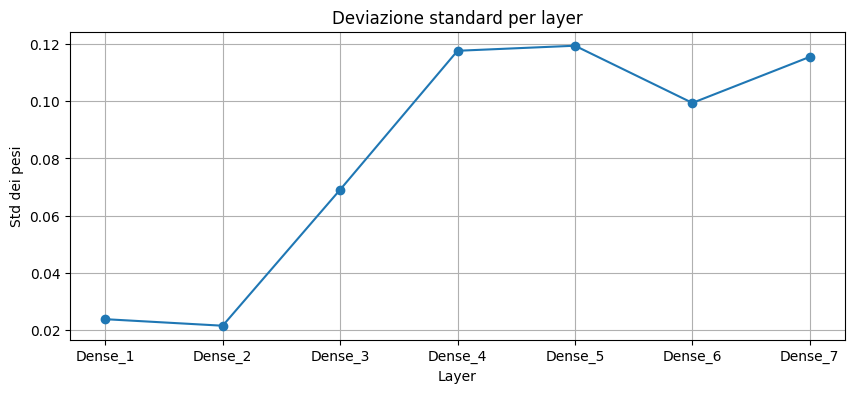

In [12]:
layer_names = []
std_weights = []
layercount = 0

for layer in model.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        w = weights[0].flatten()
        layercount += 1
        layer_names.append(f"Dense_{layercount}")
        std_weights.append(np.std(w))

plt.figure(figsize=(10, 4))
plt.plot(layer_names, std_weights, marker='o')
plt.title("Deviazione standard per layer")
plt.xlabel("Layer")
plt.ylabel("Std dei pesi")
plt.grid(True)
plt.savefig("grafici/ds-layer.png")
plt.show()

#Modello con problemi risolti

In [13]:
se = 42
tf.random.set_seed(se)
np.random.seed(se)
tf.config.experimental.enable_op_determinism()

input_dim = X_train.shape[1]
reg = 0.0001

model2 = Sequential()
model2.add(Dense(4096, activation='relu', input_dim=input_dim,
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model2.add(Dropout(0.3, seed=se))
model2.add(Dense(2048, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model2.add(Dropout(0.3, seed=se))
model2.add(Dense(1024, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model2.add(Dropout(0.3, seed=se))
model2.add(Dense(1024, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model2.add(Dropout(0.3, seed=se))
model2.add(Dense(512, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model2.add(Dropout(0.3, seed=se))
model2.add(Dense(256, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se),
                 kernel_regularizer=regularizers.l2(reg)))
model2.add(Dropout(0.3, seed=se))
model2.add(Dense(10, activation='softmax',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))

optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model2.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 4096)           │    12,587,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,784,138 (94.54 MB)

 Trainable params: 24,784,138 (94.54 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start = time.time()
history2 = model2.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop]
)
end = time.time()
print("Training time:", end-start)

Epoch 1/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 40s 131ms/step - accuracy: 0.1254 - loss: 8.0032 - val_accuracy: 0.1947 - val_loss: 7.0147
Epoch 2/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.1750 - loss: 6.5901 - val_accuracy: 0.2356 - val_loss: 6.1165
Epoch 3/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.2312 - loss: 5.7920 - val_accuracy: 0.2867 - val_loss: 5.3725
Epoch 4/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.2820 - loss: 5.1205 - val_accuracy: 0.3474 - val_loss: 4.7449
Epoch 5/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.3123 - loss: 4.5576 - val_accuracy: 0.3585 - val_loss: 4.2399
Epoch 6/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 32s 110ms/step - accuracy: 0.3278 - loss: 4.0800 - val_accuracy: 0.3719 - val_loss: 3.7751
Epoch 7/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 32s 110ms/step - accuracy: 0.3427 - loss: 3.6608 - val_accuracy: 0.3891 - val_loss: 3.4018
Epoch 8/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 32s 111ms/step - accuracy: 0.3559 -

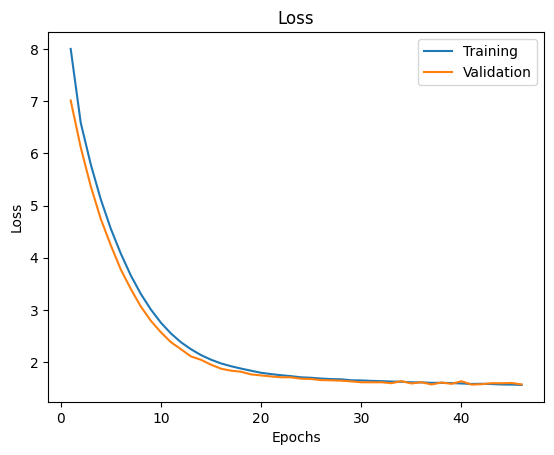

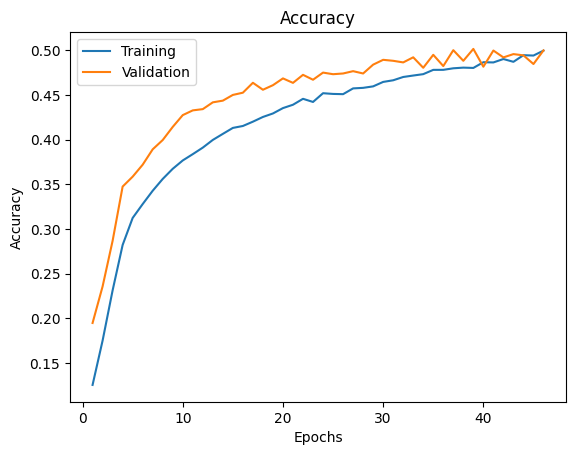

In [15]:
def plot_loss(history):
  x_plot = list(range(1,len(history.history["loss"])+1))
  plt.figure()
  plt.title("Loss")
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.plot(x_plot, history.history['loss'])
  plt.plot(x_plot, history.history['val_loss'])
  plt.legend(['Training', 'Validation'])

def plot_accuracy(history):
  x_plot = list(range(1,len(history.history["accuracy"])+1))
  plt.figure()
  plt.title("Accuracy")
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.plot(x_plot, history.history['accuracy'])
  plt.plot(x_plot, history.history['val_accuracy'])
  plt.legend(['Training', 'Validation'])

plot_loss(history2)
plt.savefig("grafici/loss2.png")
plot_accuracy(history2)
plt.savefig("grafici/accuracy2.png")

In [16]:
loss2, accuracy2 = model2.evaluate(X_test, Y_test)
print(f"Test Loss: {loss2:.4f}")
print(f"Test Accuracy: {accuracy2:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4997 - loss: 1.5690
Test Loss: 1.5690
Test Accuracy: 0.4997


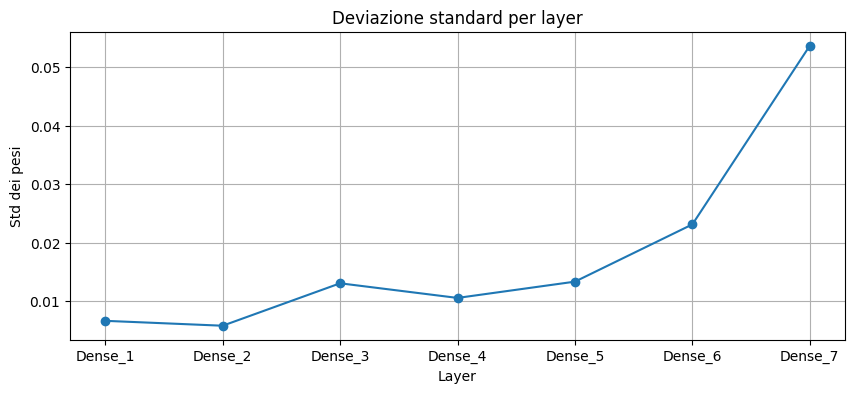

In [17]:
layer_names = []
std_weights = []
layercount = 0

for layer in model2.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        w = weights[0].flatten()
        layercount += 1
        layer_names.append(f"Dense_{layercount}")
        std_weights.append(np.std(w))

plt.figure(figsize=(10, 4))
plt.plot(layer_names, std_weights, marker='o')
plt.title("Deviazione standard per layer")
plt.xlabel("Layer")
plt.ylabel("Std dei pesi")
plt.grid(True)
plt.savefig("grafici/ds-layer2.png")
plt.show()